(30, 6)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object
         Date    Open    High     Low   Close   Volume
0  2024-01-01  152.48  157.46  150.20  153.38  3299580
1  2024-01-02  182.88  186.11  180.39  180.78  1697412
2  2024-01-03  169.51  173.28  164.73  168.13  3447829
3  2024-01-04  158.24  160.87  153.92  159.30  2680873
4  2024-01-05  194.55  196.16  191.82  194.57  2924982
             Open        High         Low       Close        Volume
count   30.000000   30.000000   30.000000   30.000000  3.000000e+01
mean   170.200667  172.865667  167.472333  170.460000  2.820409e+06
std     14.639327   14.113845   14.296799   13.891009  1.166188e+06
min    150.080000  154.650000  147.430000  153.330000  1.013606e+06
25%    157.745000  160.457500  155.407500  159.255000  1.949897e+06
50%    168.950000  171.465000  165.185000  167.455000  2.6

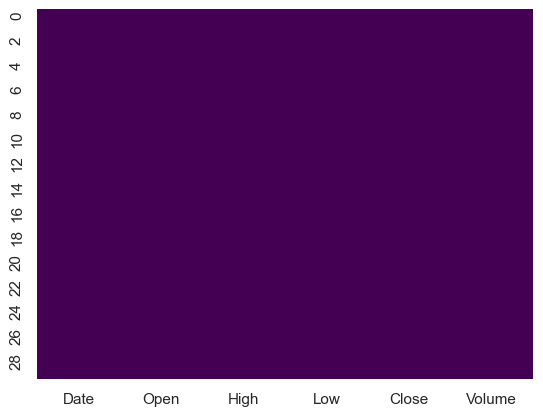

0


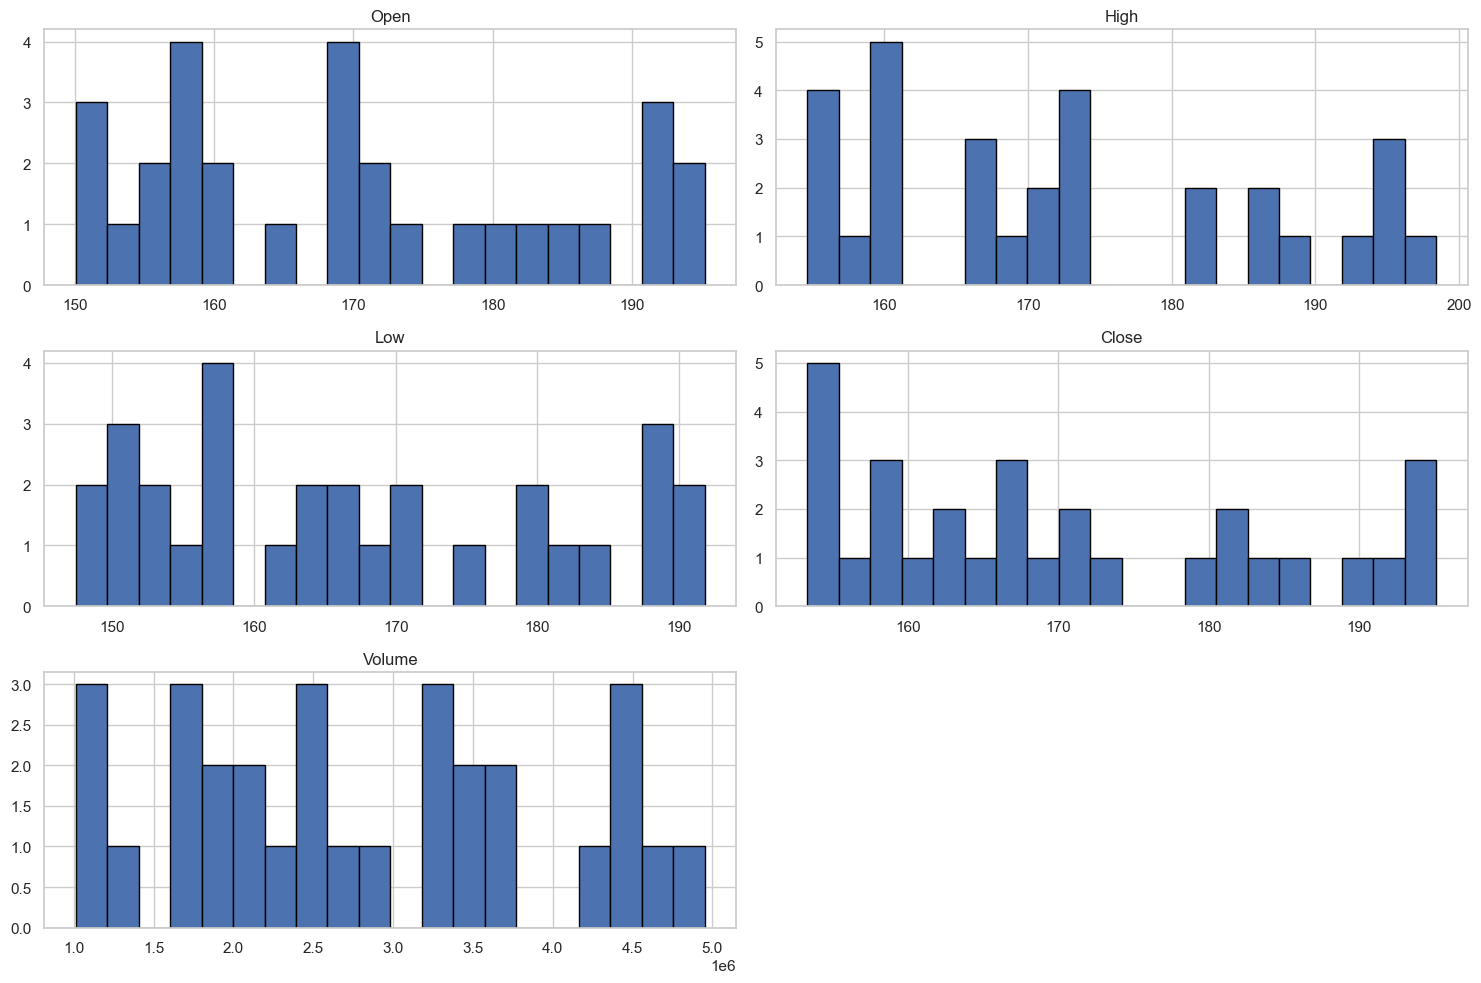

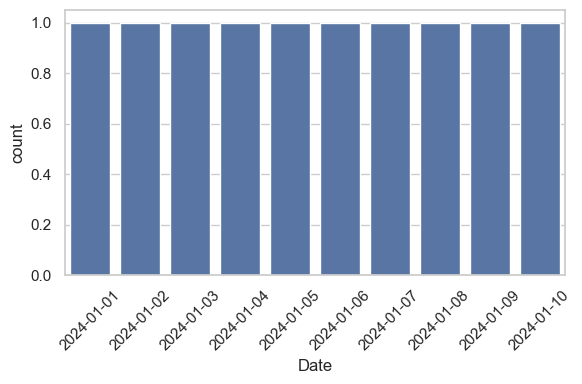

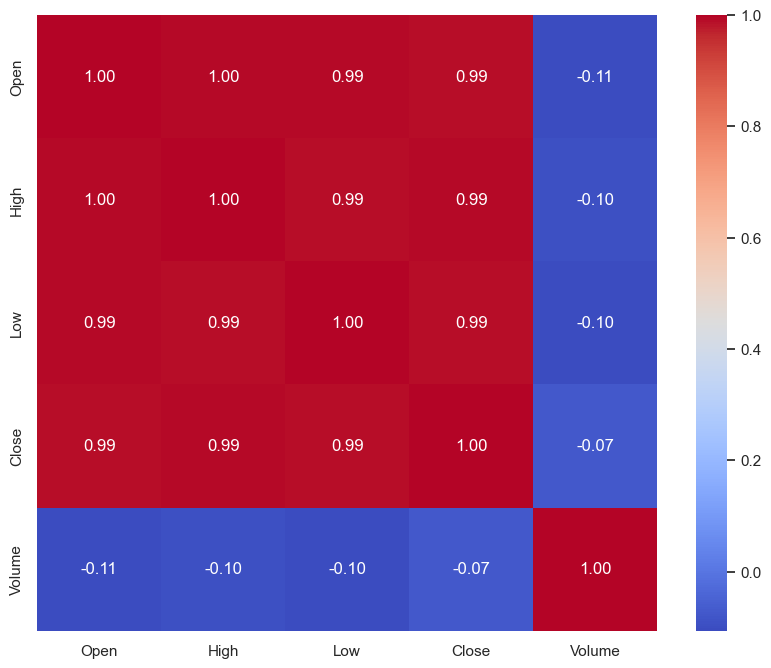

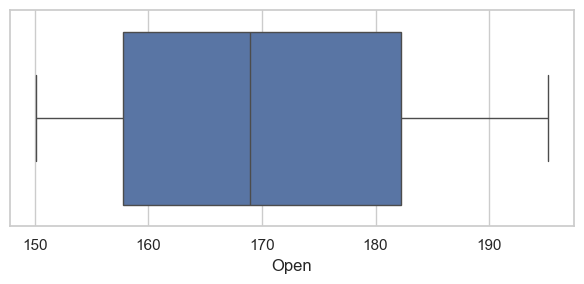

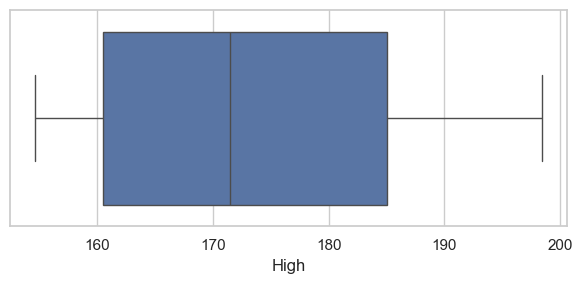

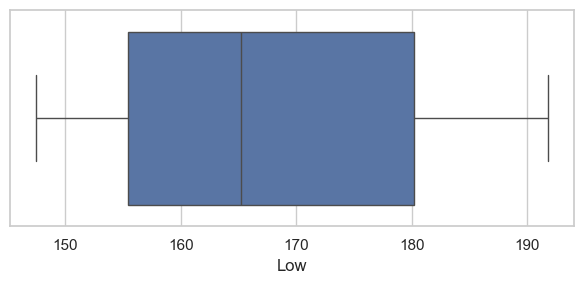

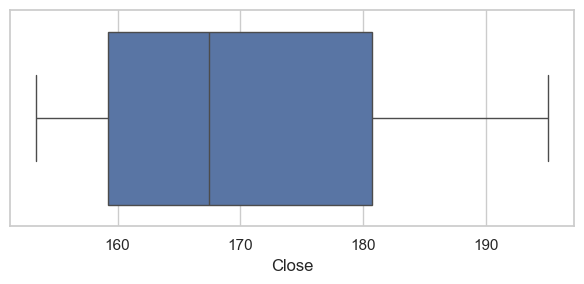

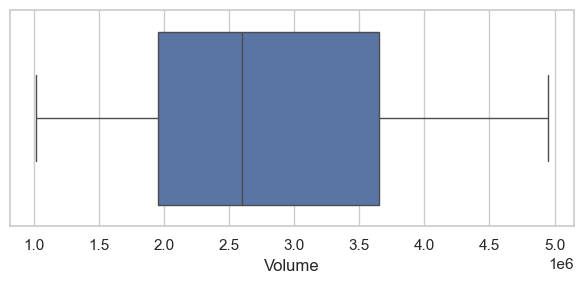

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

df = pd.read_csv("META.csv")

print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.head())
print(df.describe())

print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.show()

print(df.duplicated().sum())

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

df[numeric_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

for col in categorical_cols[:5]:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index[:10])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.show()

for col in numeric_cols[:5]:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.tight_layout()
    plt.show()


Rows and Columns: (30, 6)
Column Names:
 Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

Data Types:
 Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Missing Values:
 Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Duplicate Rows: 0


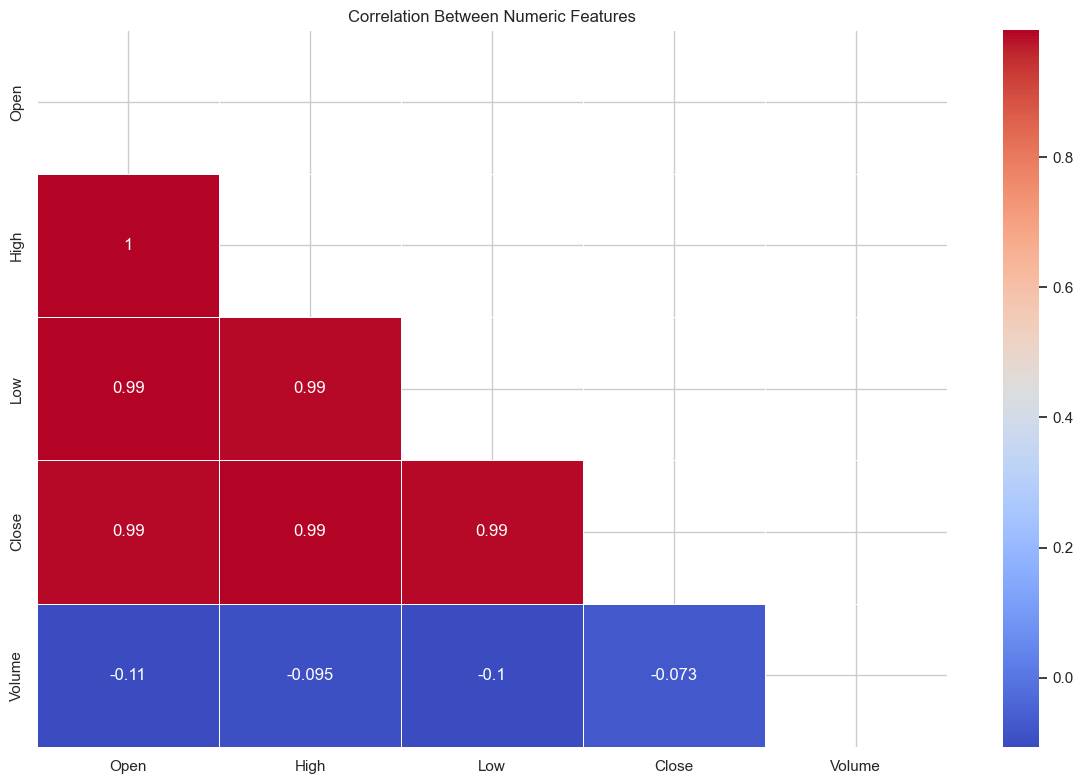

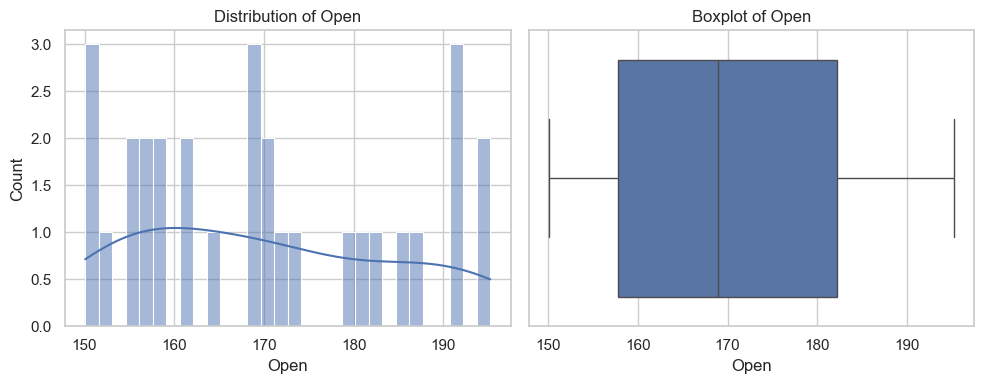

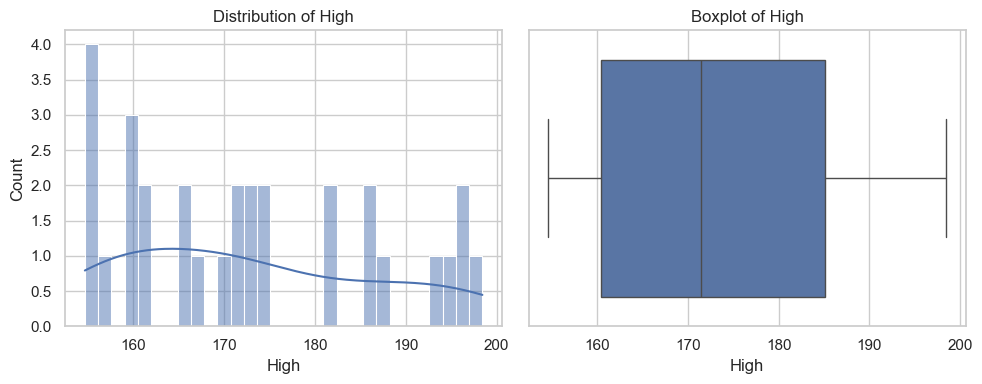

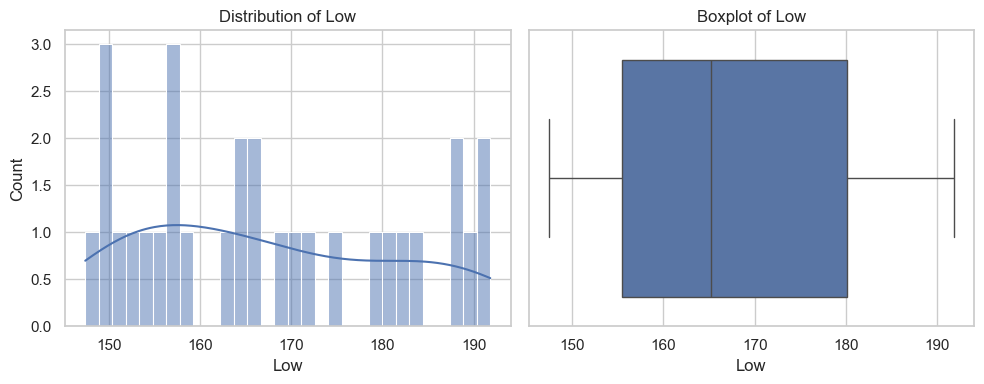

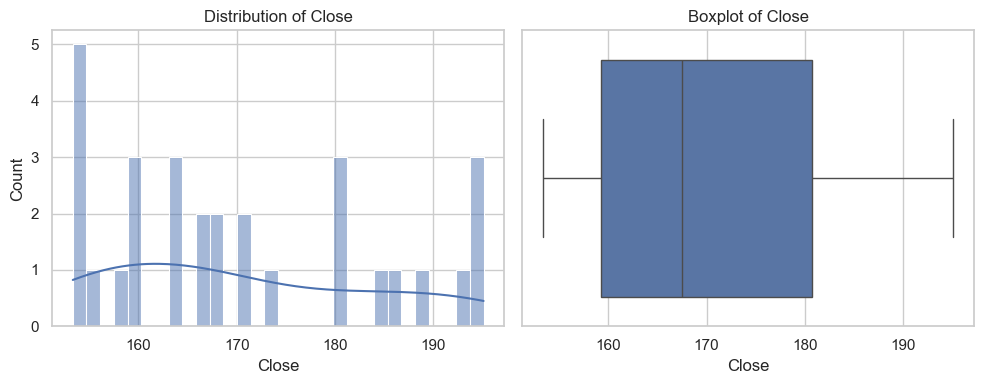

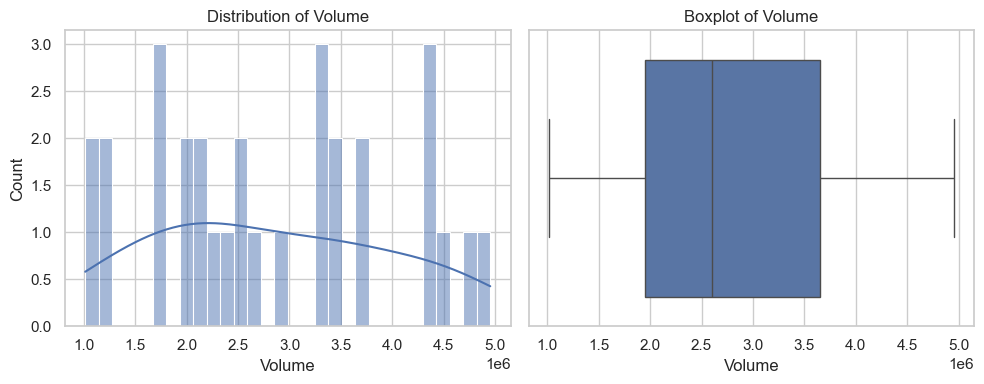


Top 5 Most Skewed Features:
 Close     0.453037
High      0.416630
Low       0.326580
Open      0.310531
Volume    0.184909
dtype: float64

Top 5 Highest Kurtosis Features:
 Volume   -1.075435
Close    -1.095069
High     -1.098833
Open     -1.203345
Low      -1.237773
dtype: float64


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore, skew, kurtosis

data = pd.read_csv("META.csv")

print("Rows and Columns:", data.shape)
print("Column Names:\n", data.columns)
print("\nData Types:\n", data.dtypes)
print("\nMissing Values:\n", data.isnull().sum())
print("Duplicate Rows:", data.duplicated().sum())

numeric_columns = data.select_dtypes(include=np.number).columns
categorical_columns = data.select_dtypes(include="object").columns

data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].median())
for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

for col in categorical_columns:
    if data[col].nunique() < 20:
        encoder = LabelEncoder()
        data[col] = encoder.fit_transform(data[col].astype(str))

z_scores = zscore(data[numeric_columns])
filtered_data = data[(np.abs(z_scores) < 3).all(axis=1)]

plt.figure(figsize=(12, 8))
correlation = filtered_data[numeric_columns].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

for col in numeric_columns[:5]:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(filtered_data[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.subplot(1, 2, 2)
    sns.boxplot(x=filtered_data[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

skewness = filtered_data[numeric_columns].apply(skew).sort_values(ascending=False)
kurtosis_values = filtered_data[numeric_columns].apply(kurtosis).sort_values(ascending=False)

print("\nTop 5 Most Skewed Features:\n", skewness.head())
print("\nTop 5 Highest Kurtosis Features:\n", kurtosis_values.head())


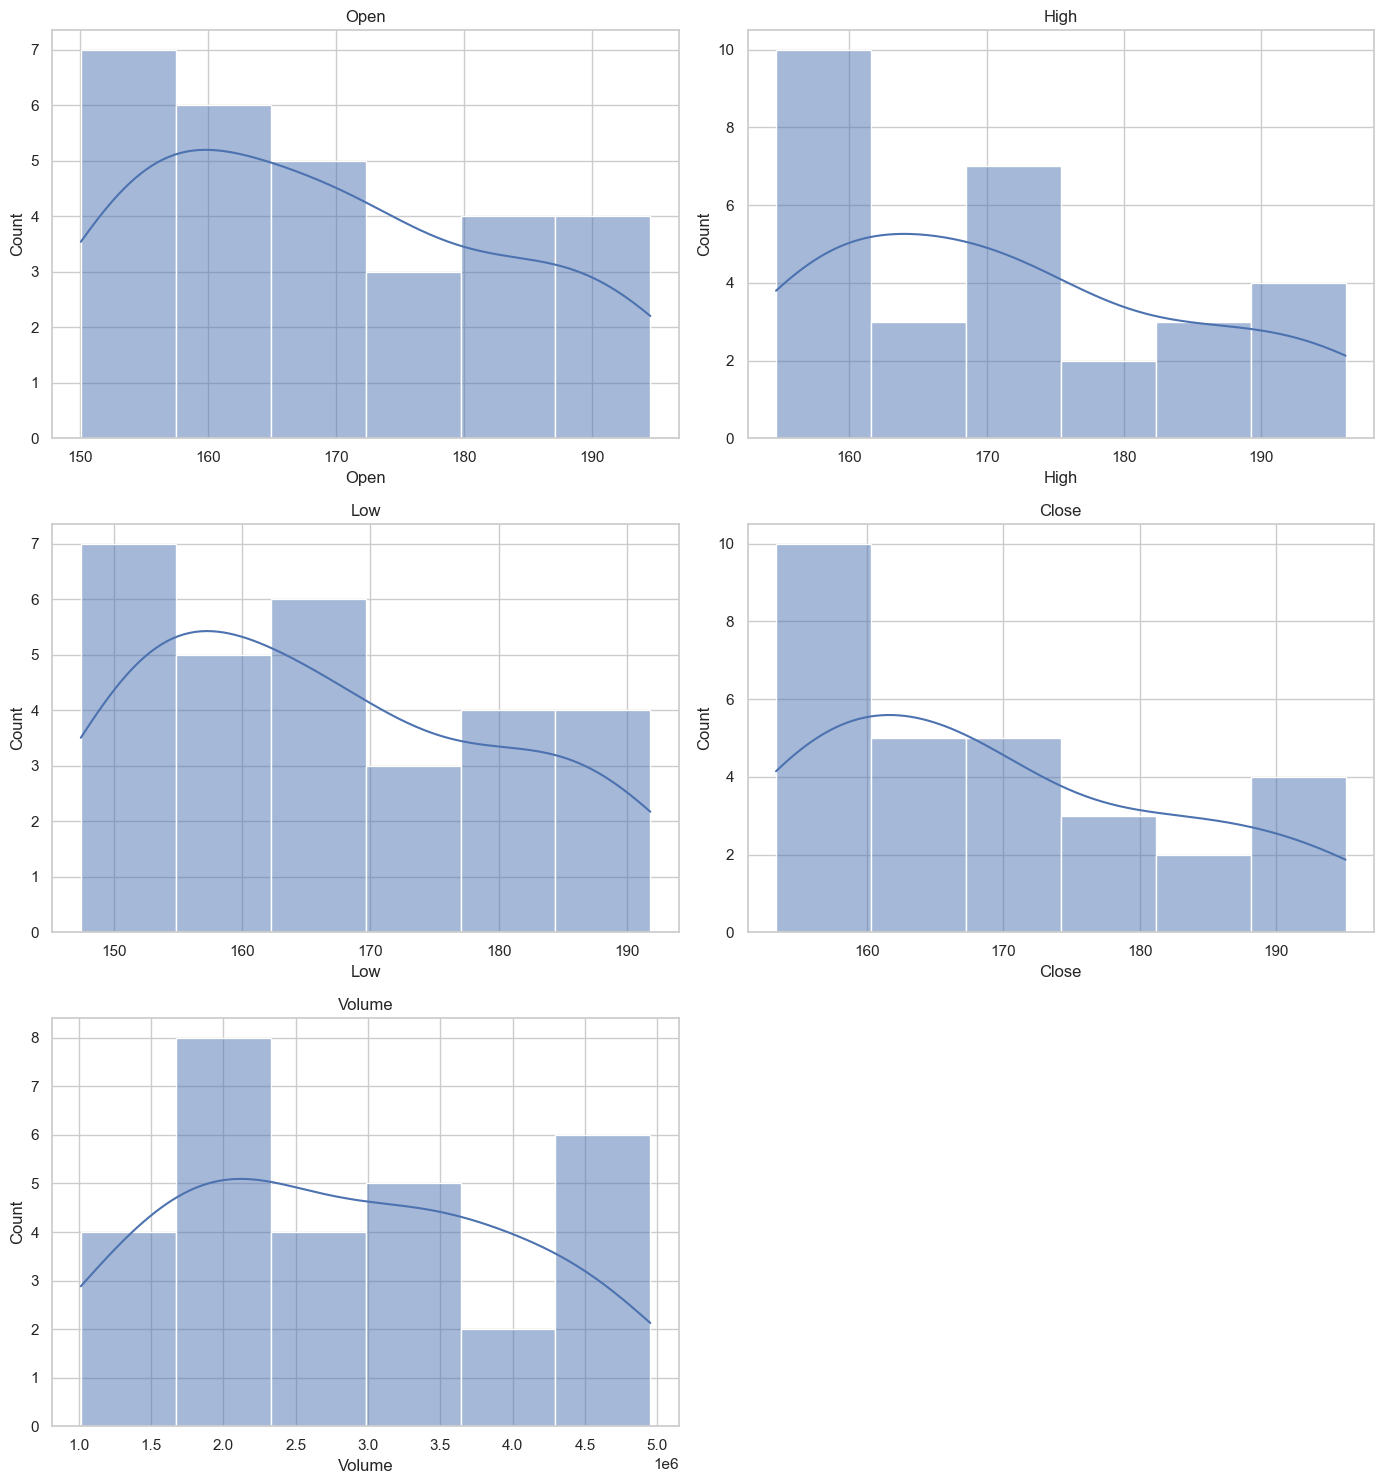

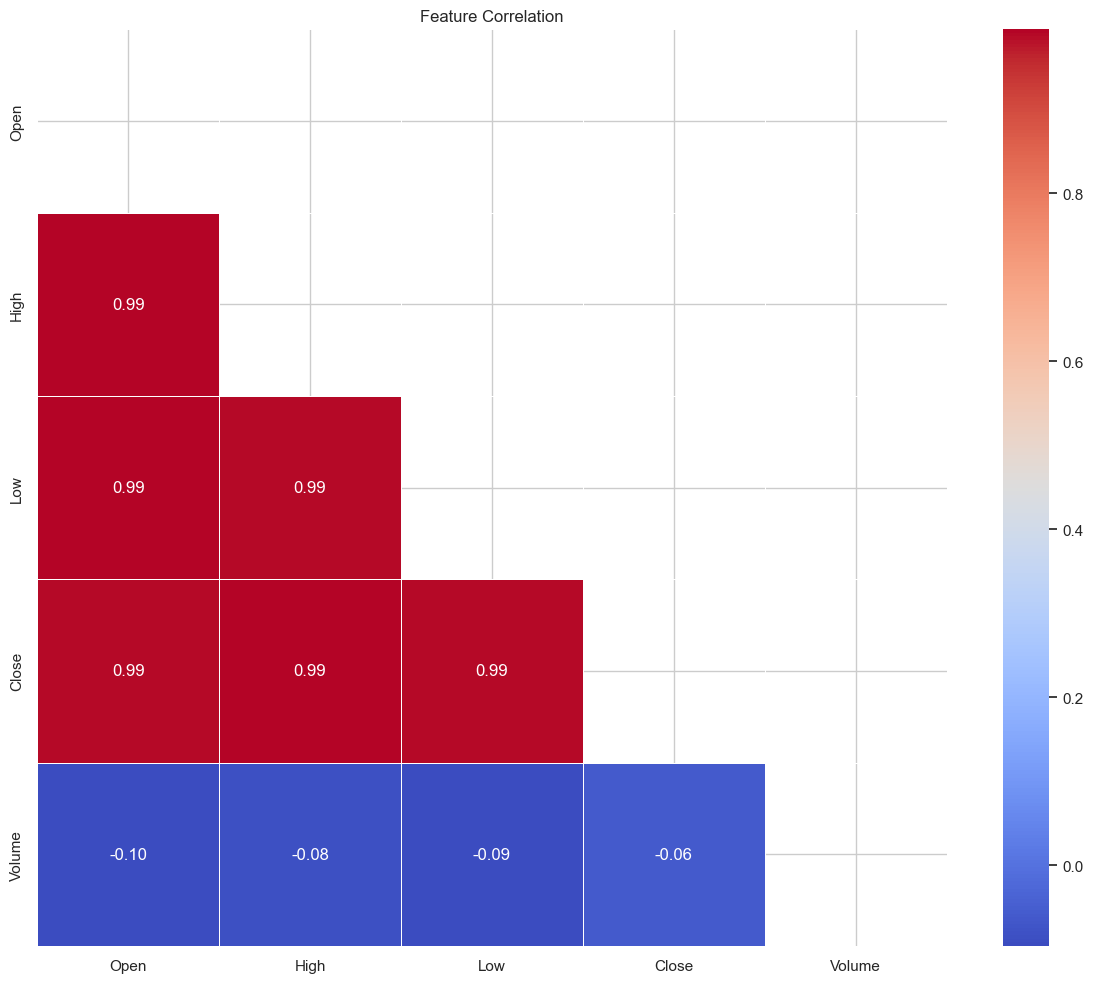


Top Skewed Features:
 Close     0.514461
High      0.446597
Low       0.377038
Open      0.344252
Volume    0.155933
dtype: float64

Top Kurtotic Features:
 Close    -0.958885
High     -1.026275
Volume   -1.136728
Open     -1.139631
Low      -1.149778
dtype: float64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import IsolationForest
from scipy.stats import skew, kurtosis

warnings.filterwarnings("ignore")

df = pd.read_csv("META.csv")
numeric = df.select_dtypes(include=np.number).columns
categorical = df.select_dtypes(exclude=np.number).columns

df[numeric] = df[numeric].apply(lambda x: x.fillna(x.median()))
for col in categorical:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df = df.loc[:, ~df.columns.duplicated()]
df = df.loc[:, df.nunique() > 1]

z = np.abs((df[numeric] - df[numeric].mean()) / df[numeric].std())
df = df[(z < 3).all(axis=1)]

outlier_model = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
outliers = outlier_model.fit_predict(df[numeric])
df = df[outliers == 1]

num_cols = len(numeric)
rows = (num_cols + 1) // 2
fig, axs = plt.subplots(rows, 2, figsize=(14, 5 * rows))
axs = axs.ravel()

for i, col in enumerate(numeric):
    sns.histplot(df[col], kde=True, ax=axs[i])
    axs[i].set_title(col)

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

corr = df[numeric].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

sk = df[numeric].apply(skew).sort_values(ascending=False)
ku = df[numeric].apply(kurtosis).sort_values(ascending=False)

print("\nTop Skewed Features:\n", sk.head())
print("\nTop Kurtotic Features:\n", ku.head())

if 'target' in df.columns:
    mi = pd.Series(mutual_info_classif(df[numeric], df['target']), index=numeric)
    mi = mi.sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=mi, y=mi.index, palette="viridis")
    plt.title("Feature Importance via Mutual Info")
    plt.tight_layout()
    plt.show()

    class_counts = df['target'].value_counts(normalize=True)
    plt.figure(figsize=(6, 4))
    sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette="Set2")
    plt.title("Class Distribution")
    plt.tight_layout()
    plt.show()
